In [2]:
# Cell 1
import keras
import numpy as np
import matplotlib.pyplot as plt
from keras import layers

print(keras.__version__)


2.15.0


In [3]:
# Cell 2
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
assert x_train.shape == (60000, 28, 28)
assert x_test.shape == (10000, 28, 28)
assert y_train.shape == (60000,)
assert y_test.shape == (10000,)

In [4]:
x_train = x_train/255.0
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test/255.0
x_test = x_test.reshape(-1, 28, 28, 1)

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("Valore minimo:", x_train.min(), "— Valore massimo:", x_train.max())

x_train shape: (60000, 28, 28, 1)
x_test shape: (10000, 28, 28, 1)
Valore minimo: 0.0 — Valore massimo: 1.0



```
Input (28, 28, 1)
   ↓
Conv2D + ReLU + MaxPool
   ↓
Conv2D + ReLU + MaxPool
   ↓
Flatten
   ↓
Dense + ReLU
   ↓
Dense + Softmax (10 classi)
```


In [23]:
model = keras.Sequential()
model.add(keras.Input(shape=(28, 28, 1)))
model.add(keras.layers.Conv2D(16, kernel_size=5, padding="same", activation="relu"))
model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))
model.add(keras.layers.Dropout(.25))
model.add(keras.layers.Conv2D(32, kernel_size=5, padding="same", activation="relu"))
model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))
model.add(keras.layers.Dropout(.25))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dropout(.4))
model.add(keras.layers.Dense(128, activation="relu"))
model.add(keras.layers.Dense(10, activation="softmax"))

model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_11 (Conv2D)          (None, 28, 28, 16)        416       
                                                                 
 max_pooling2d_10 (MaxPooli  (None, 14, 14, 16)        0         
 ng2D)                                                           
                                                                 
 dropout_1 (Dropout)         (None, 14, 14, 16)        0         
                                                                 
 conv2d_12 (Conv2D)          (None, 14, 14, 32)        12832     
                                                                 
 max_pooling2d_11 (MaxPooli  (None, 7, 7, 32)          0         
 ng2D)                                                           
                                                                 
 dropout_2 (Dropout)         (None, 7, 7, 32)         

```
Input (28,28,1)
   ↓
Conv2D → (28,28,16)   padding='same' mantiene le dimensioni spaziali
   ↓
MaxPool → (14,14,16)  dimezza da 28 a 14
   ↓
Conv2D → (14,14,32)   padding='same' mantiene le dimensioni spaziali
   ↓
MaxPool → (7,7,32)    dimezza da 14 a 7
   ↓
Flatten → 7×7×32 = 1568
   ↓
Dense → 128
   ↓
Dense → 10
```

215.370 parametri totali — tutti addestrabili.

---

In [24]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

callback = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

history = model.fit(
    x=x_train,
    y=y_train,
    batch_size=32,
    epochs=10,
    validation_split=0.2,
    callbacks=[callback]
)


Epoch 1/10
1500/1500 [==============================] - 23s 14ms/step - loss: 0.5541 - accuracy: 0.7981 - val_loss: 0.3686 - val_accuracy: 0.8705
Epoch 2/10
1500/1500 [==============================] - 19s 13ms/step - loss: 0.3861 - accuracy: 0.8589 - val_loss: 0.3152 - val_accuracy: 0.8890
Epoch 3/10
1500/1500 [==============================] - 22s 15ms/step - loss: 0.3416 - accuracy: 0.8737 - val_loss: 0.2886 - val_accuracy: 0.8917
Epoch 4/10
1500/1500 [==============================] - 23s 16ms/step - loss: 0.3180 - accuracy: 0.8818 - val_loss: 0.2647 - val_accuracy: 0.9018
Epoch 5/10
1500/1500 [==============================] - 21s 14ms/step - loss: 0.3021 - accuracy: 0.8881 - val_loss: 0.2690 - val_accuracy: 0.9008
Epoch 6/10
1500/1500 [==============================] - 19s 13ms/step - loss: 0.2864 - accuracy: 0.8924 - val_loss: 0.2504 - val_accuracy: 0.9067
Epoch 7/10
1500/1500 [==============================] - 19s 12ms/step - loss: 0.2775 - accuracy: 0.8970 - val_loss: 0.2474 -

In [25]:
test_loss, test_acc = model.evaluate(
    x=x_test,
    y=y_test,
    batch_size=32
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

313/313 [==============================] - 2s 5ms/step - loss: 0.2683 - accuracy: 0.8986
Test Loss: 0.2683
Test Accuracy: 0.8986


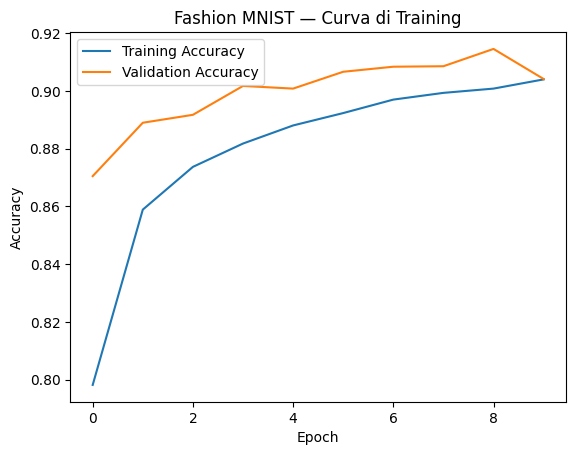

In [26]:
plt.plot(history.history['accuracy'],     label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Fashion MNIST — Curva di Training')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()